In [ ]:
!pip install tensorflow==2.12.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:

!pip install librosa soundfile audiomentations scikit-learn imbalanced-learn xgboost lightgbm -q
!pip install tensorflow keras numpy pandas matplotlib seaborn tqdm joblib -q
import warnings, os
warnings.filterwarnings('ignore')
print('All dependencies installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 30.0 MB/s eta 0:00:00
All dependencies installed!


In [ ]:

import os
from google.colab import drive
drive.mount('/content/drive')


DRIVE_FOLDER_PATH = '/content/drive/MyDrive/archive/donateacry_corpus'
EXTRACT_DIR = '/content/cry_dataset'

os.makedirs(EXTRACT_DIR, exist_ok=True)

import shutil
print("Copying files from Drive to Colab (this may take a few minutes)...")

if os.path.exists(DRIVE_FOLDER_PATH):
   
    for item in os.listdir(DRIVE_FOLDER_PATH):
        source = os.path.join(DRIVE_FOLDER_PATH, item)
        destination = os.path.join(EXTRACT_DIR, item)
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)

    print(f'Copied to {EXTRACT_DIR}')
else:
    print(f"ERROR: Folder not found at {DRIVE_FOLDER_PATH}")
    print("Please check the path. Available contents in MyDrive:")
    print(os.listdir('/content/drive/MyDrive/'))


DATASET_DIR = EXTRACT_DIR


CLASSES = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])
print(f'\nClasses ({len(CLASSES)}): {CLASSES}')

for c in CLASSES:
    class_path = os.path.join(DATASET_DIR, c)
    wav_files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
    print(f'  {c:<20s}: {len(wav_files)} files')



Mounted at /content/drive
Copying files from Drive to Colab (this may take a few minutes)...
Copied to /content/cry_dataset

Classes (5): ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']
  belly_pain          : 16 files
  burping             : 8 files
  discomfort          : 27 files
  hungry              : 382 files
  tired               : 24 files


In [ ]:

import numpy as np, random, tensorflow as tf
import os 


DATASET_DIR = '/content/cry_dataset'
CLASSES = ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']


CFG = {
    'sample_rate' : 22050,
    'duration'    : 4,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'hop_length'  : 512,
    'n_fft'       : 2048,
    'fmax'        : 8000,
    'mel_width'   : 173,
    'batch_size'  : 32,
    'epochs'      : 80,
    'lr'          : 1e-3,
    'val_split'   : 0.15,
    'test_split'  : 0.15,
    'seed'        : 42,
    'augment'     : True,
    'aug_factor'  : 3,
    'dataset_dir' : DATASET_DIR,
    'model_dir'   : '/content/models',
    'classes'     : CLASSES,
}
NUM_CLASSES = len(CLASSES)
MAX_LEN     = CFG['sample_rate'] * CFG['duration']
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
tf.random.set_seed(CFG['seed'])
os.makedirs(CFG['model_dir'], exist_ok=True)
gpu = tf.config.list_physical_devices('GPU')
print(f'Config ready | Classes: {NUM_CLASSES} | GPU available: {bool(gpu)}')

Config ready | Classes: 5 | GPU available: True


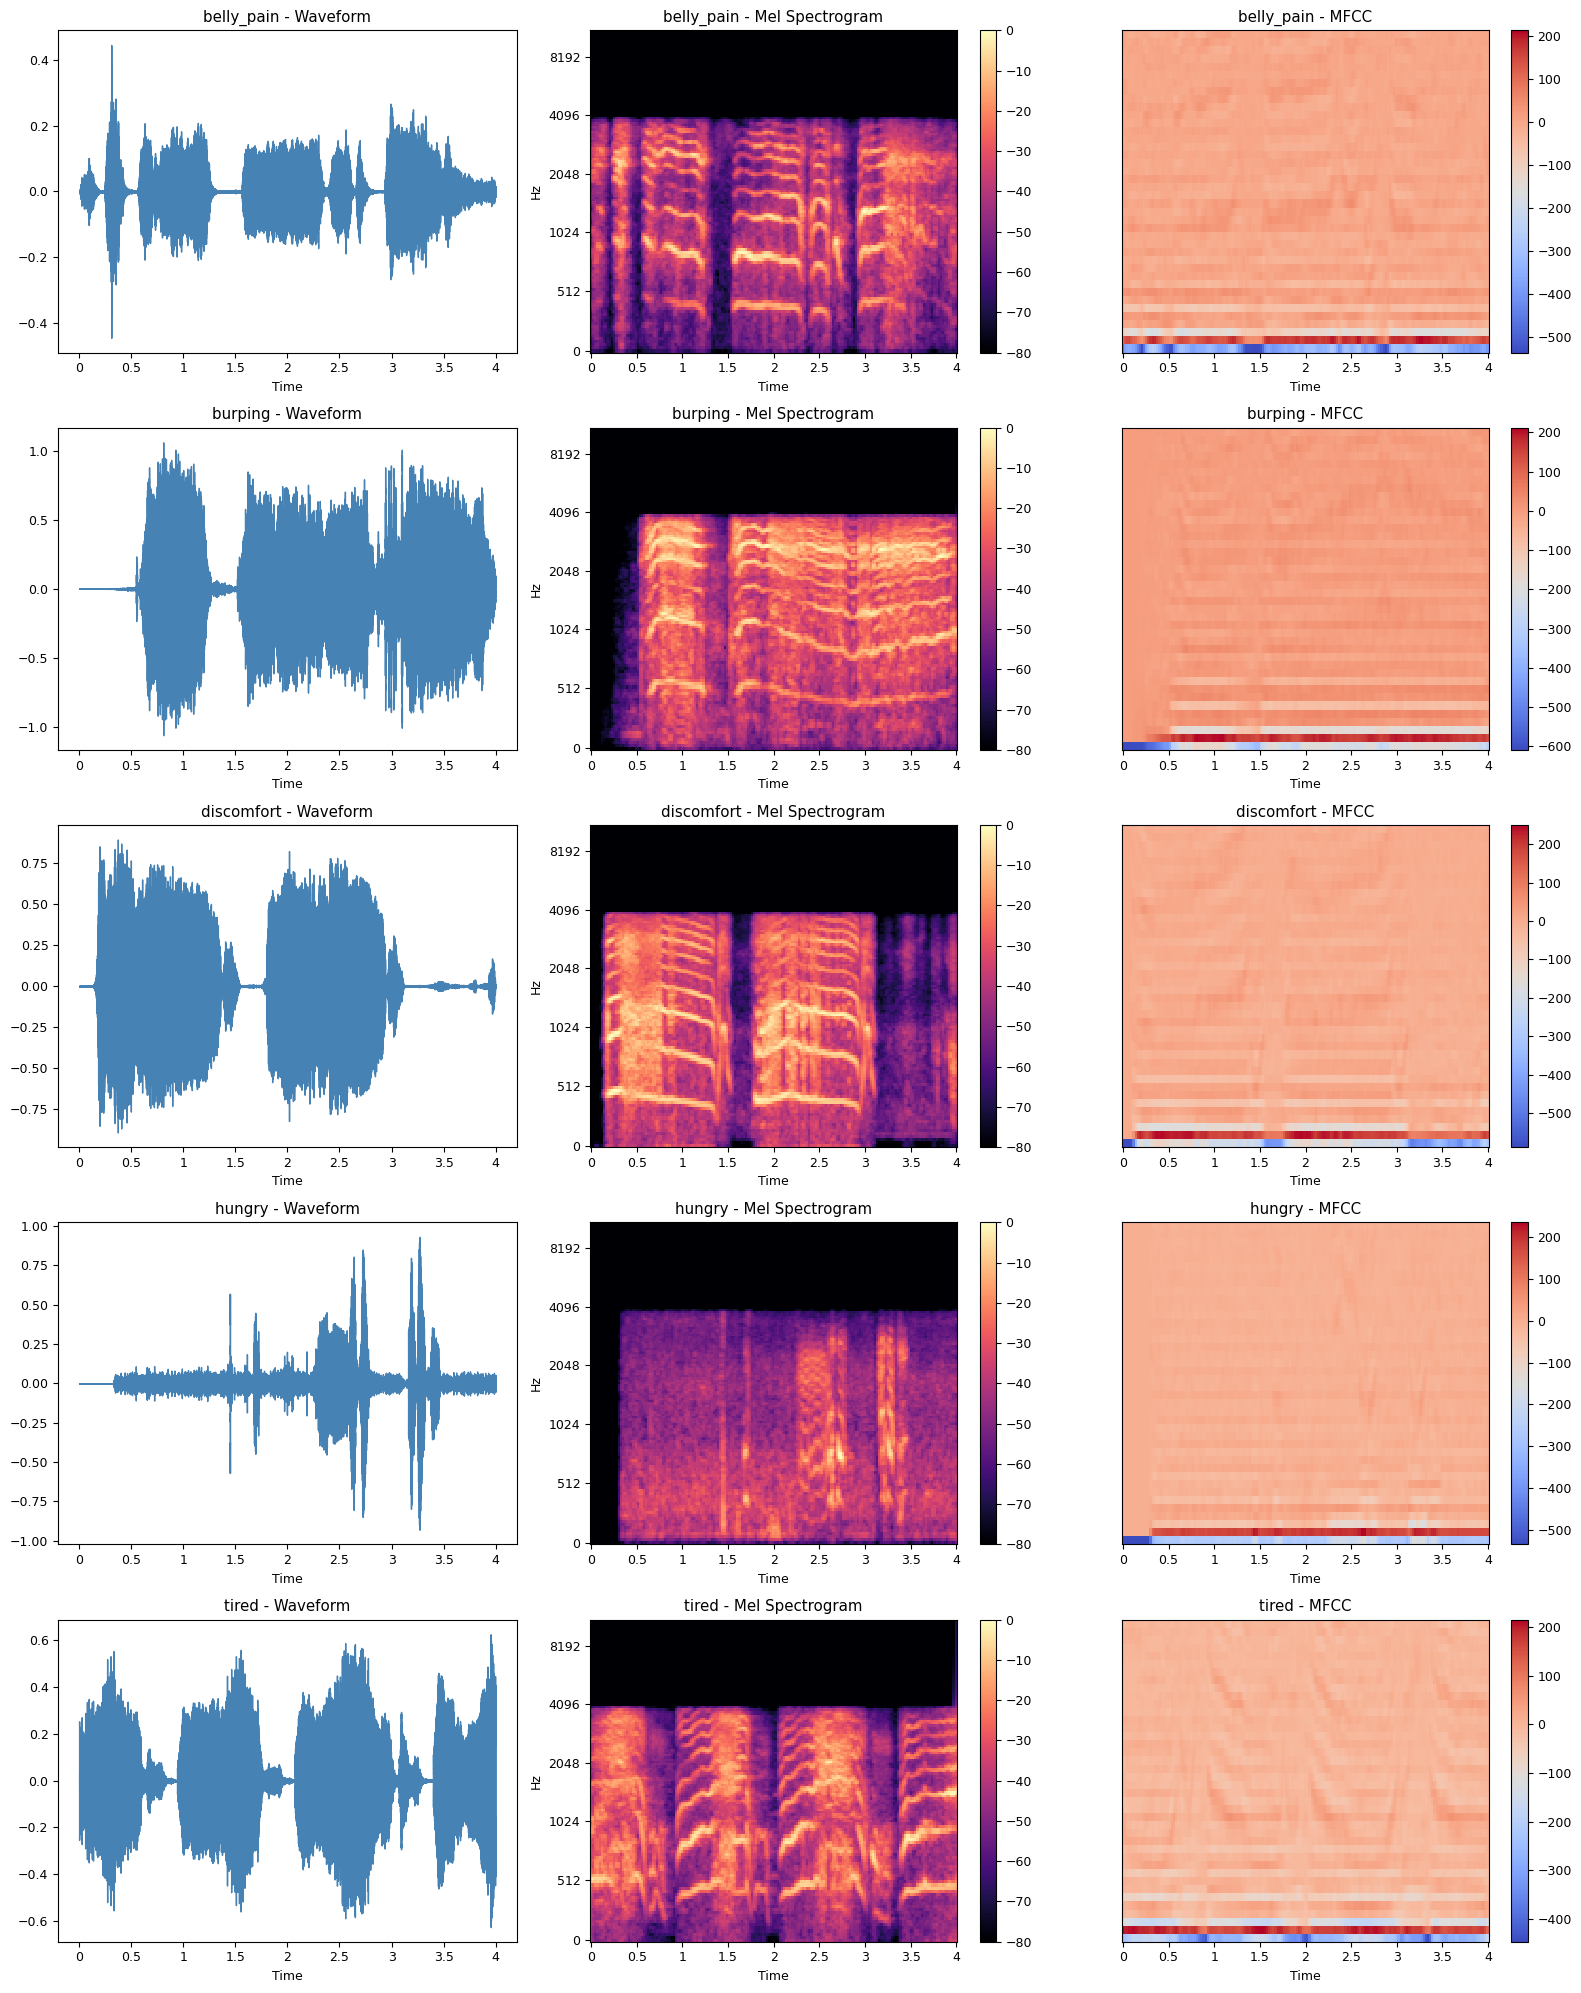

EDA complete


In [ ]:

import librosa, librosa.display, matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 9})
fig = plt.figure(figsize=(16, 4 * NUM_CLASSES))

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(CFG['dataset_dir'], cls)

   
    if not os.path.isdir(cls_dir):
        print(f"Warning: Directory '{cls_dir}' not found. Skipping {cls} class for EDA.")
        continue

    wavs = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
    if not wavs:
        print(f"Warning: No .wav files found in '{cls_dir}'. Skipping {cls} class for EDA.")
        continue

    y, sr   = librosa.load(os.path.join(cls_dir, wavs[0]),
                            sr=CFG['sample_rate'], duration=CFG['duration'])

    ax1 = fig.add_subplot(NUM_CLASSES, 3, i*3+1)
    librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title(f'{cls} - Waveform')

    ax2  = fig.add_subplot(NUM_CLASSES, 3, i*3+2)
    mel  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG['n_mels'])
    mdb  = librosa.power_to_db(mel, ref=np.max)
    img  = librosa.display.specshow(mdb, sr=sr, ax=ax2, cmap='magma', x_axis='time', y_axis='mel')
    fig.colorbar(img, ax=ax2)
    ax2.set_title(f'{cls} - Mel Spectrogram')

    ax3  = fig.add_subplot(NUM_CLASSES, 3, i*3+3)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG['n_mfcc'])
    img2 = librosa.display.specshow(mfcc, sr=sr, ax=ax3, cmap='coolwarm', x_axis='time')
    fig.colorbar(img2, ax=ax3)
    ax3.set_title(f'{cls} - MFCC')

plt.tight_layout()
plt.savefig('/content/eda.png', bbox_inches='tight')
plt.show()
print('EDA complete')

In [ ]:

!pip install audiomentations -q
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

AUGMENT = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5),
    PitchShift(min_semitones=-3, max_semitones=3, p=0.4),
    Shift(min_shift=-0.3, max_shift=0.3, p=0.3),
])

def augment_audio(y, sr, n=2):
    results = []
    for _ in range(n):
        try:
            results.append(AUGMENT(samples=y.astype(np.float32), sample_rate=sr))
        except Exception:
            results.append(y.copy())
    return results

print('Augmentation pipeline ready')

Augmentation pipeline ready


In [ ]:

def load_pad(path, sr, max_len):
    try:
        y, _ = librosa.load(path, sr=sr)
    except Exception:
        return None
    y = librosa.util.normalize(y)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    return y[:max_len].astype(np.float32)

def extract_1d(y, sr):
    feats = []
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG['n_mfcc'],
                                   n_fft=CFG['n_fft'], hop_length=CFG['hop_length'])
    for arr in [mfcc, librosa.feature.delta(mfcc), librosa.feature.delta(mfcc, order=2)]:
        feats += [arr.mean(1), arr.std(1), arr.max(1), arr.min(1)]
    mel   = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG['n_mels'],
                                            n_fft=CFG['n_fft'], hop_length=CFG['hop_length'])
    mdb   = librosa.power_to_db(mel, ref=np.max)
    feats += [mdb.mean(1), mdb.std(1)]
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=CFG['n_fft'], hop_length=CFG['hop_length'])
    feats += [chroma.mean(1), chroma.std(1)]
    for fn in [
        lambda: librosa.feature.spectral_centroid(y=y, sr=sr),
        lambda: librosa.feature.spectral_bandwidth(y=y, sr=sr),
        lambda: librosa.feature.spectral_rolloff(y=y, sr=sr),
        lambda: librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=CFG['n_fft']),
        lambda: librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr),
        lambda: librosa.feature.zero_crossing_rate(y),
        lambda: librosa.feature.rms(y=y),
    ]:
        a = fn()
        feats += [a.mean(1), a.std(1)]
    try:
        f0, _, _ = librosa.pyin(y, fmin=50, fmax=1000, sr=sr)
        f0c = f0[~np.isnan(f0)] if f0 is not None else np.array([0.0])
        feats.append(np.array([f0c.mean(), f0c.std(), f0c.max()] if len(f0c) else [0,0,0]))
    except Exception:
        feats.append(np.array([0.0, 0.0, 0.0]))
    return np.concatenate([f.flatten() for f in feats]).astype(np.float32)

def extract_2d(y, sr):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG['n_mels'],
                                          n_fft=CFG['n_fft'], hop_length=CFG['hop_length'],
                                          fmax=CFG['fmax'])
    mdb = librosa.power_to_db(mel, ref=np.max)
    w   = CFG['mel_width']
    if mdb.shape[1] < w:
        mdb = np.pad(mdb, ((0,0),(0, w - mdb.shape[1])))
    return mdb[:, :w].astype(np.float32)

print('Feature functions ready')

Feature functions ready


In [ ]:

from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X1_all, X2_all, y_all = [], [], []
label_enc = LabelEncoder()
label_enc.fit(CLASSES)

for cls in tqdm(CLASSES, desc='Classes'):
    cls_dir = os.path.join(CFG['dataset_dir'], cls)
    wavs    = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
    lbl     = label_enc.transform([cls])[0]
    for fname in tqdm(wavs, desc=f'  {cls}', leave=False):
        ya = load_pad(os.path.join(cls_dir, fname), CFG['sample_rate'], MAX_LEN)
        if ya is None: continue
        X1_all.append(extract_1d(ya, CFG['sample_rate']))
        X2_all.append(extract_2d(ya, CFG['sample_rate']))
        y_all.append(lbl)
        if CFG['augment']:
            for aug in augment_audio(ya, CFG['sample_rate'], CFG['aug_factor']):
                X1_all.append(extract_1d(aug, CFG['sample_rate']))
                X2_all.append(extract_2d(aug, CFG['sample_rate']))
                y_all.append(lbl)

X1 = np.array(X1_all)
X2 = np.array(X2_all)[..., np.newaxis]
y  = np.array(y_all)
print(f'1D features : {X1.shape}')
print(f'2D spectrograms: {X2.shape}')
for i, c in enumerate(CLASSES):
    print(f'  {c:<20s}: {(y==i).sum()} samples')

Classes: 100%|██████████| 5/5 [32:33<00:00, 390.63s/it]

1D features : (1828, 799)
2D spectrograms: (1828, 128, 173, 1)
  belly_pain          : 64 samples
  burping             : 32 samples
  discomfort          : 108 samples
  hungry              : 1528 samples
  tired               : 96 samples


In [ ]:

import joblib

X1_tv,X1_te,X2_tv,X2_te,y_tv,y_te = train_test_split(
    X1, X2, y, test_size=CFG['test_split'], stratify=y, random_state=CFG['seed'])

vr = CFG['val_split'] / (1 - CFG['test_split'])
X1_tr,X1_va,X2_tr,X2_va,y_tr,y_va = train_test_split(
    X1_tv, X2_tv, y_tv, test_size=vr, stratify=y_tv, random_state=CFG['seed'])

scaler  = StandardScaler()
X1_tr   = scaler.fit_transform(X1_tr)
X1_va   = scaler.transform(X1_va)
X1_te   = scaler.transform(X1_te)

def norm2d(X):
    mn = X.min(axis=(1,2,3), keepdims=True)
    mx = X.max(axis=(1,2,3), keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)

X2_tr = norm2d(X2_tr)
X2_va = norm2d(X2_va)
X2_te = norm2d(X2_te)

joblib.dump(scaler, '/content/models/scaler.pkl')
np.save('/content/models/label_classes.npy', label_enc.classes_)
print(f'Train:{len(y_tr)}  Val:{len(y_va)}  Test:{len(y_te)}')

Train:1278  Val:275  Test:275


In [ ]:

from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

y_tr_c = to_categorical(y_tr, NUM_CLASSES)
y_va_c = to_categorical(y_va, NUM_CLASSES)
y_te_c = to_categorical(y_te, NUM_CLASSES)
IN2D   = X2_tr.shape[1:]

def se_block(x, r=16):
    c  = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(c//r, activation='relu')(se)
    se = layers.Dense(c, activation='sigmoid')(se)
    se = layers.Reshape((1,1,c))(se)
    return layers.Multiply()([x, se])

def conv_block(x, f, pool=(2,2)):
    x = layers.Conv2D(f,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(f,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x)
    x = layers.MaxPooling2D(pool)(x)
    return layers.Dropout(0.25)(x)

def build_cnn(in_shape, nc):
    inp = layers.Input(shape=in_shape)
    x   = conv_block(inp, 32)
    x   = conv_block(x,  64)
    x   = conv_block(x,  128)
    x   = conv_block(x,  256)
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    x   = layers.Concatenate()([gap, gmp])
    x   = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(nc, activation='softmax')(x)
    return models.Model(inp, out, name='CNN_SE')

cnn = build_cnn(IN2D, NUM_CLASSES)
cnn.compile(optimizer=optimizers.AdamW(learning_rate=CFG['lr'], weight_decay=1e-4),
            loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = dict(enumerate(cw))

cbs = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('/content/models/cnn_best.h5',
                               monitor='val_accuracy', save_best_only=True),
]

print('Training CNN-SE...')
cnn_hist = cnn.fit(X2_tr, y_tr_c, validation_data=(X2_va, y_va_c),
                   epochs=CFG['epochs'], batch_size=CFG['batch_size'],
                   callbacks=cbs, class_weight=class_weights, verbose=1)
print('CNN training complete!')

Model: "CNN_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 173,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 173,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 173,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 173,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 173,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 173,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 173,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         96 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 173,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 86,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 86,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 86,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 86,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 86,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 86,    │     36,928 │ activation_2[0][

 Total params: 1,584,227 (6.04 MB)

 Trainable params: 1,581,283 (6.03 MB)

 Non-trainable params: 2,944 (11.50 KB)

Training CNN-SE...
Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.3476 - loss: 2.0996

40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 746ms/step - accuracy: 0.3463 - loss: 2.1028 - val_accuracy: 0.8364 - val_loss: 1.2443 - learning_rate: 0.0010
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.2185 - loss: 1.9960 - val_accuracy: 0.8364 - val_loss: 0.9384 - learning_rate: 0.0010
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.2605 - loss: 1.9440 - val_accuracy: 0.0509 - val_loss: 2.3163 - learning_rate: 0.0010
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.2097 - loss: 1.8598 - val_accuracy: 0.0509 - val_loss: 1.7438 - learning_rate: 0.0010
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.2414 - loss: 1.6523 - val_accuracy: 0.0509 - val_loss: 3.8631 - learning_rate: 0.0010
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.3042 - loss: 1.5341 - val_accuracy: 0.8364 - val_loss: 1.5582 - learning_rate: 0.0010
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.2970 - loss: 1.5861 - val_accuracy: 0.

In [ ]:

IN1D = X1_tr.shape[1]

def build_hybrid(in2d, in1d, nc):
    mel_in = layers.Input(shape=in2d, name='mel')
    x = layers.Conv2D(64,(3,3), activation='relu', padding='same')(mel_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Conv2D(256,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h, w*c))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3, implementation=2))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3, implementation=2))(x)
    q = layers.Dense(64)(x)
    k = layers.Dense(64)(x)
    v = layers.Dense(128)(x)
    sc = layers.Dot(axes=[2,2])([q,k])
    sc = layers.Softmax()(sc)
    x  = layers.Dot(axes=[2,1])([sc,v])
    x  = layers.GlobalAveragePooling1D()(x)
    fi = layers.Input(shape=(in1d,), name='feat')
    f  = layers.Dense(512, activation='relu')(fi)
    f  = layers.BatchNormalization()(f)
    f  = layers.Dropout(0.4)(f)
    f  = layers.Dense(256, activation='relu')(f)
    f  = layers.BatchNormalization()(f)
    f  = layers.Dropout(0.3)(f)
    f  = layers.Dense(128, activation='relu')(f)
    m  = layers.Concatenate()([x, f])
    m  = layers.Dense(256, activation='relu')(m)
    m  = layers.BatchNormalization()(m)
    m  = layers.Dropout(0.4)(m)
    m  = layers.Dense(128, activation='relu')(m)
    m  = layers.Dropout(0.3)(m)
    out = layers.Dense(nc, activation='softmax')(m)
    return models.Model([mel_in, fi], out, name='CNN_BiLSTM_Attn')

hybrid = build_hybrid(IN2D, IN1D, NUM_CLASSES)
hybrid.compile(optimizer=optimizers.AdamW(learning_rate=CFG['lr']*0.5, weight_decay=1e-4),
               loss='categorical_crossentropy', metrics=['accuracy'])
hybrid.summary()

cbs2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('/content/models/hybrid_best.h5',
                               monitor='val_accuracy', save_best_only=True),
]

print('Training CNN-BiLSTM-Attention...')
hyb_hist = hybrid.fit([X2_tr, X1_tr], y_tr_c,
                       validation_data=([X2_va, X1_va], y_va_c),
                       epochs=CFG['epochs'], batch_size=CFG['batch_size'],
                       callbacks=cbs2, class_weight=class_weights, verbose=1)
print('Hybrid training complete!')

Model: "CNN_BiLSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel (InputLayer)    │ (None, 128, 173,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 173,  │        640 │ mel[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 173,  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 86,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 86,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 86,    │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 21,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 21,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 21,    │      1,024 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 10,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 16, 2560)  │          0 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat (InputLayer)   │ (None, 799)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 16, 512)   │  5,769,216 │ reshape_4[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 512)       │    409,600 │ feat[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 16, 256)   │    656,384 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16, 64)    │     16,448 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16, 64)    │     16,448 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,540,101 (28.76 MB)

 Trainable params: 7,537,157 (28.75 MB)

 Non-trainable params: 2,944 (11.50 KB)

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.8644 - loss: 0.1718 - val_accuracy: 0.8545 - val_loss: 0.5548 - learning_rate: 2.5000e-04
Epoch 39/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.8551 - loss: 0.1244 - val_accuracy: 0.8364 - val_loss: 0.5554 - learning_rate: 2.5000e-04
Epoch 40/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.8777 - loss: 0.0850 - val_accuracy: 0.8364 - val_loss: 0.5161 - learning_rate: 2.5000e-04
Epoch 41/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9123 - loss: 0.1388 - val_accuracy: 0.8436 - val_loss: 0.5963 - learning_rate: 2.5000e-04
Epoch 42/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.8900 - loss: 0.1129 - val_accuracy: 0.8545 - val_loss: 0.5309 - learning_rate: 2.5000e-04
Epoch 43/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.8981 - loss: 0.0688 - val_accuracy: 0.8545 - val_loss: 0.5556 - learning_rate: 2.5000e-04
Epoch 44/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.933

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.9334 - loss: 0.0587 - val_accuracy: 0.8727 - val_loss: 0.5509 - learning_rate: 2.5000e-04
Epoch 45/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9271 - loss: 0.0611

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.9272 - loss: 0.0611 - val_accuracy: 0.8800 - val_loss: 0.5350 - learning_rate: 2.5000e-04
Epoch 46/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.9376 - loss: 0.0600 - val_accuracy: 0.8655 - val_loss: 0.5693 - learning_rate: 2.5000e-04
Epoch 47/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9421 - loss: 0.0519
Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9423 - loss: 0.0518 - val_accuracy: 0.8836 - val_loss: 0.5315 - learning_rate: 2.5000e-04
Epoch 48/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9356 - loss: 0.0573 - val_accuracy: 0.8836 - val_loss: 0.5098 - learning_rate: 1.2500e-04
Epoch 49/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9467 - loss: 0.0483

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.9467 - loss: 0.0482 - val_accuracy: 0.8909 - val_loss: 0.5014 - learning_rate: 1.2500e-04
Epoch 50/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9517 - loss: 0.0457 - val_accuracy: 0.8800 - val_loss: 0.4957 - learning_rate: 1.2500e-04
Epoch 51/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.9544 - loss: 0.0653 - val_accuracy: 0.8836 - val_loss: 0.4928 - learning_rate: 1.2500e-04
Epoch 52/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9446 - loss: 0.0446 - val_accuracy: 0.8800 - val_loss: 0.5131 - learning_rate: 1.2500e-04
Epoch 53/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9614 - loss: 0.0404 - val_accuracy: 0.8909 - val_loss: 0.4968 - learning_rate: 1.2500e-04
Epoch 54/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9586 - loss: 0.0426 - val_accuracy: 0.8873 - val_loss: 0.4960 - learning_rate: 1.2500e-04
Epoch 55/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.96

In [ ]:

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import lightgbm as lgb

pca      = PCA(n_components=150, random_state=CFG['seed'])
X1_tr_p  = pca.fit_transform(X1_tr)
X1_va_p  = pca.transform(X1_va)
X1_te_p  = pca.transform(X1_te)
joblib.dump(pca, '/content/models/pca.pkl')
print(f'PCA: {X1_tr.shape[1]} -> {X1_tr_p.shape[1]} dims')

rf   = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               random_state=CFG['seed'], n_jobs=-1)
xgb  = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric='mlogloss', random_state=CFG['seed'], n_jobs=-1)
lgbm = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                            class_weight='balanced', random_state=CFG['seed'], n_jobs=-1)
svm  = SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced')

ml_ens = VotingClassifier(
    estimators=[('rf',rf),('xgb',xgb),('lgb',lgbm),('svm',svm)],
    voting='soft', n_jobs=-1)

print('Training ML Ensemble (RF + XGBoost + LightGBM + SVM)...')
ml_ens.fit(X1_tr_p, y_tr)
joblib.dump(ml_ens, '/content/models/ml_ensemble.pkl')
print('ML ensemble training complete!')

PCA: 799 -> 150 dims
Training ML Ensemble (RF + XGBoost + LightGBM + SVM)...
ML ensemble training complete!


9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step
CNN-SE Accuracy: 83.64%
              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00        10
     burping       0.00      0.00      0.00         5
  discomfort       0.00      0.00      0.00        16
      hungry       0.84      1.00      0.91       230
       tired       0.00      0.00      0.00        14

    accuracy                           0.84       275
   macro avg       0.17      0.20      0.18       275
weighted avg       0.70      0.84      0.76       275



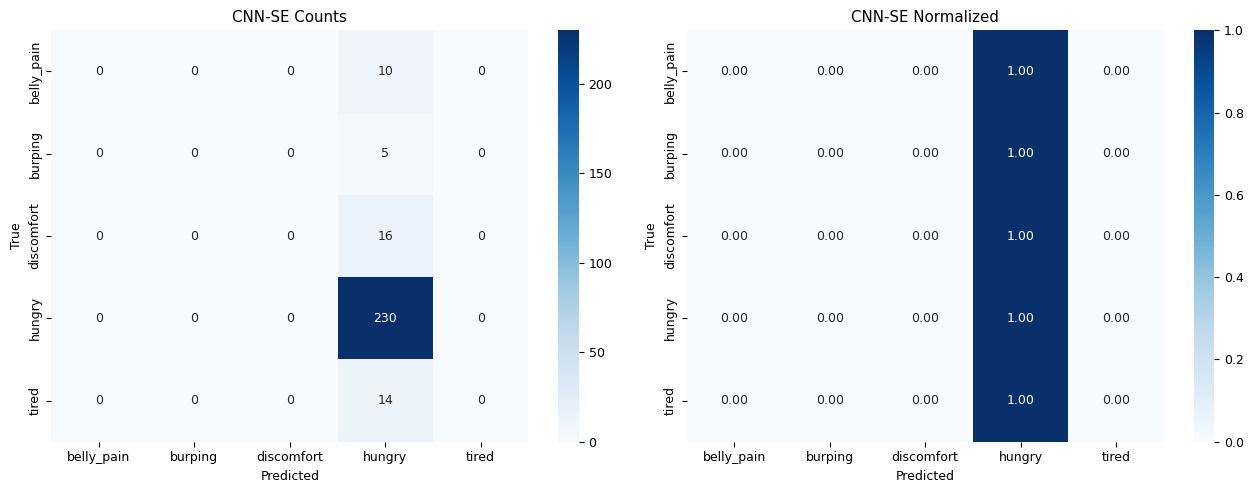

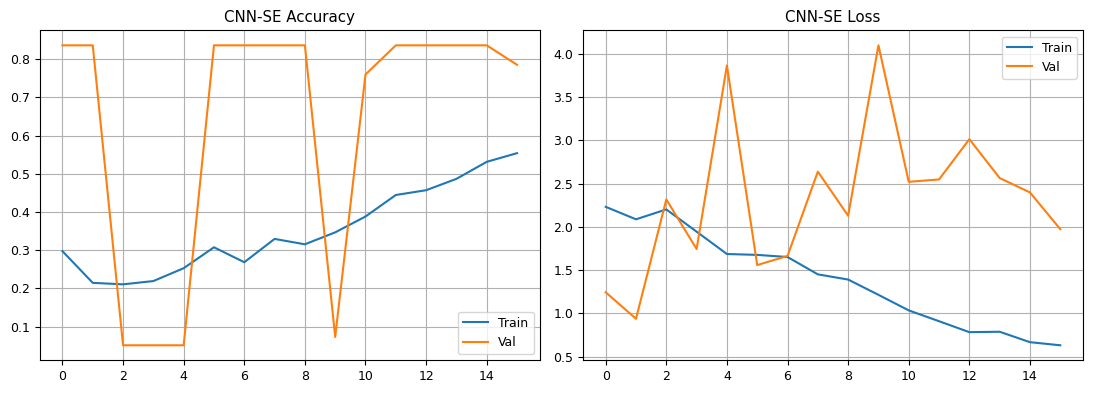

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
CNN-BiLSTM Accuracy: 89.82%
              precision    recall  f1-score   support

  belly_pain       0.69      0.90      0.78        10
     burping       0.43      0.60      0.50         5
  discomfort       0.70      0.88      0.78        16
      hungry       0.96      0.93      0.94       230
       tired       0.67      0.57      0.62        14

    accuracy                           0.90       275
   macro avg       0.69      0.77      0.72       275
weighted avg       0.91      0.90      0.90       275



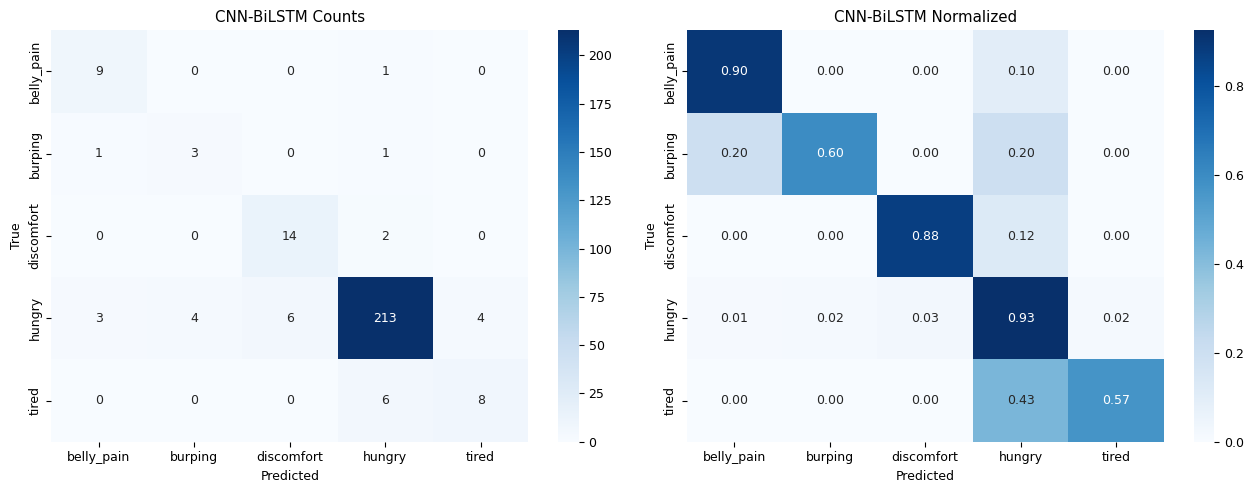

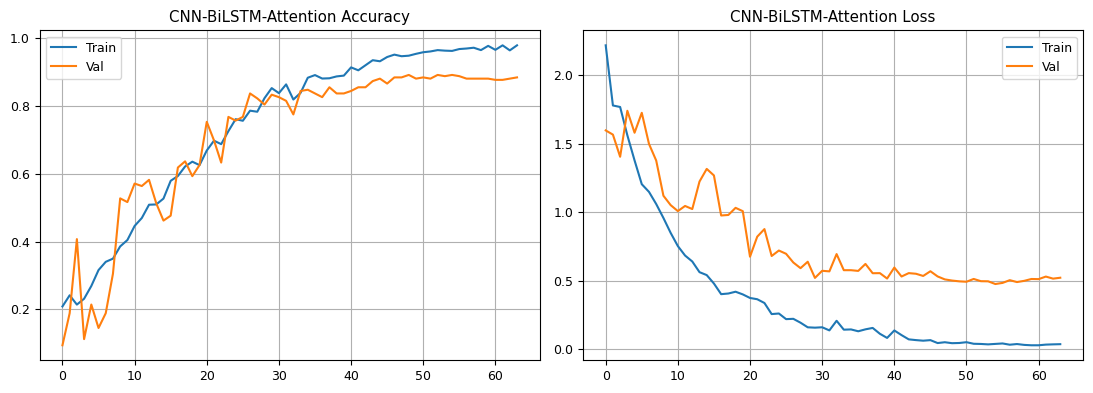

ML Ensemble Accuracy: 88.00%
              precision    recall  f1-score   support

  belly_pain       1.00      0.30      0.46        10
     burping       1.00      0.20      0.33         5
  discomfort       1.00      0.38      0.55        16
      hungry       0.87      1.00      0.93       230
       tired       1.00      0.14      0.25        14

    accuracy                           0.88       275
   macro avg       0.97      0.40      0.50       275
weighted avg       0.90      0.88      0.85       275



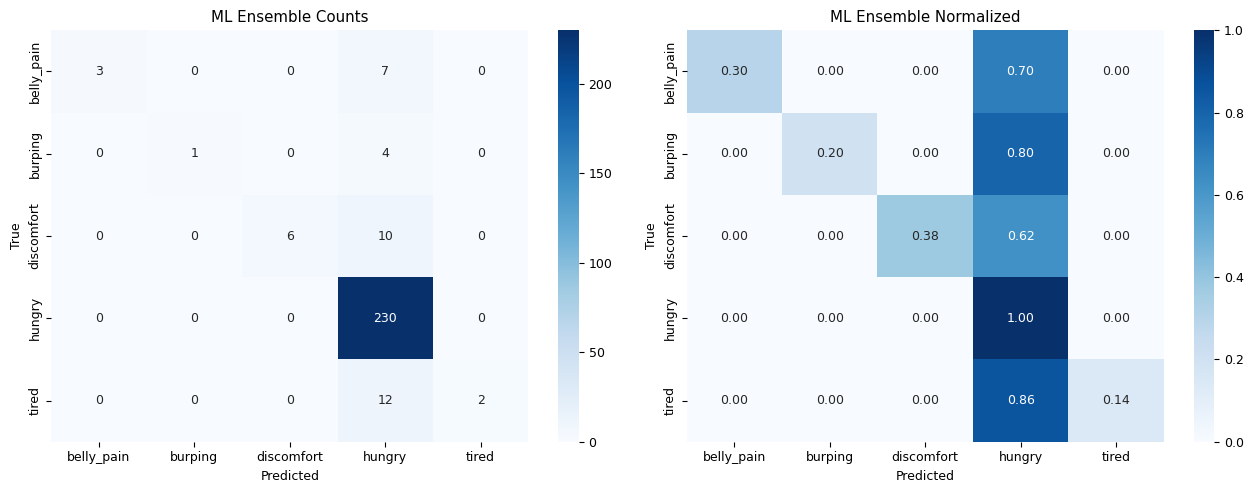

FINAL ENSEMBLE ACCURACY: 93.45%


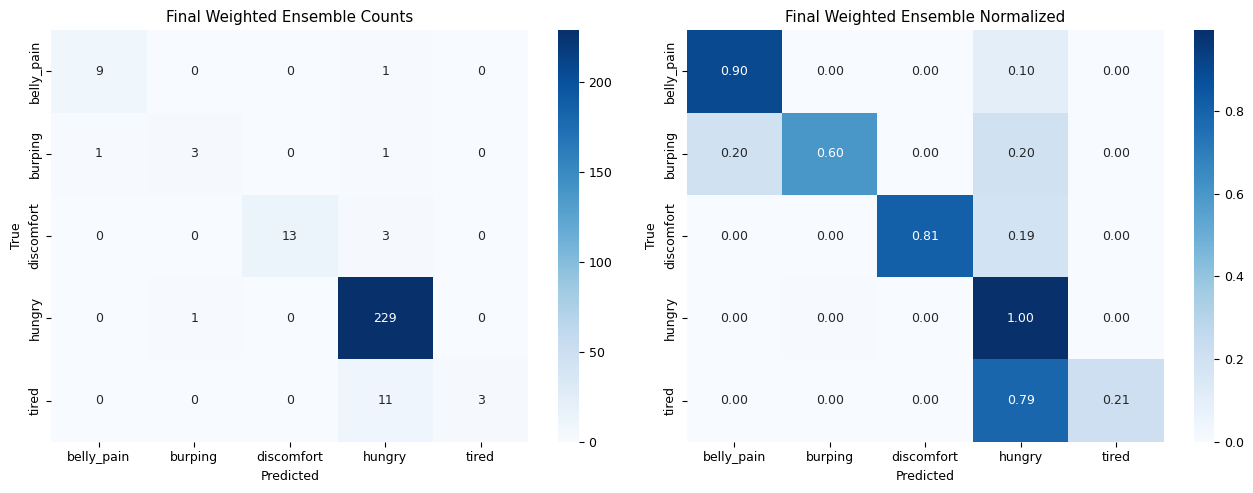

Weights -> CNN:0.321  Hybrid:0.342  ML:0.337


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    cmn  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1,2,figsize=(13,5))
    for ax,data,fmt,t in zip(axes,[cm,cmn],['d','.2f'],[title+' Counts',title+' Normalized']):
        sns.heatmap(data,annot=True,fmt=fmt,cmap='Blues',
                    xticklabels=CLASSES,yticklabels=CLASSES,ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(t)
    plt.tight_layout(); plt.show()

def plot_history(hist, title):
    fig,(a,b) = plt.subplots(1,2,figsize=(11,4))
    a.plot(hist.history['accuracy'],label='Train')
    a.plot(hist.history['val_accuracy'],label='Val')
    a.set_title(f'{title} Accuracy'); a.legend(); a.grid(True)
    b.plot(hist.history['loss'],label='Train')
    b.plot(hist.history['val_loss'],label='Val')
    b.set_title(f'{title} Loss'); b.legend(); b.grid(True)
    plt.tight_layout(); plt.show()

# CNN
cnn_p   = cnn.predict(X2_te)
cnn_acc = (cnn_p.argmax(1)==y_te).mean()
print(f'CNN-SE Accuracy: {cnn_acc*100:.2f}%')
print(classification_report(y_te, cnn_p.argmax(1), target_names=CLASSES))
plot_cm(y_te, cnn_p.argmax(1), 'CNN-SE')
plot_history(cnn_hist, 'CNN-SE')

hyb_p   = hybrid.predict([X2_te, X1_te])
hyb_acc = (hyb_p.argmax(1)==y_te).mean()
print(f'CNN-BiLSTM Accuracy: {hyb_acc*100:.2f}%')
print(classification_report(y_te, hyb_p.argmax(1), target_names=CLASSES))
plot_cm(y_te, hyb_p.argmax(1), 'CNN-BiLSTM')
plot_history(hyb_hist, 'CNN-BiLSTM-Attention')


ml_p   = ml_ens.predict_proba(X1_te_p)
ml_acc = (ml_p.argmax(1)==y_te).mean()
print(f'ML Ensemble Accuracy: {ml_acc*100:.2f}%')
print(classification_report(y_te, ml_p.argmax(1), target_names=CLASSES))
plot_cm(y_te, ml_p.argmax(1), 'ML Ensemble')


cnn_va = max(cnn_hist.history['val_accuracy'])
hyb_va = max(hyb_hist.history['val_accuracy'])
ml_va  = ml_ens.score(X1_va_p, y_va)
total  = cnn_va + hyb_va + ml_va
wc,wh,wm = cnn_va/total, hyb_va/total, ml_va/total
ens_p  = wc*cnn_p + wh*hyb_p + wm*ml_p
ens_acc = (ens_p.argmax(1)==y_te).mean()
print(f'FINAL ENSEMBLE ACCURACY: {ens_acc*100:.2f}%')
plot_cm(y_te, ens_p.argmax(1), 'Final Weighted Ensemble')
np.save('/content/models/ensemble_weights.npy', np.array([wc,wh,wm]))
print(f'Weights -> CNN:{wc:.3f}  Hybrid:{wh:.3f}  ML:{wm:.3f}')

In [ ]:

import tensorflow as tf, shutil, json, os
from tensorflow.keras import layers, models, regularizers

os.makedirs('/content/models', exist_ok=True)

def convert_tflite(model, name, rep_data=None):
  
    save_path = f'/content/models/{name}.keras' 
    out_path  = f'/content/models/{name}.tflite'

    
    model.save(save_path) 

    if rep_data is not None:
        try:
            print(f'  Trying INT8 quantization for {name}...')
            conv = tf.lite.TFLiteConverter.from_saved_model(save_path)
            conv.optimizations = [tf.lite.Optimize.DEFAULT]
            conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
            conv.inference_input_type  = tf.float32   
            conv.inference_output_type = tf.float32
            def gen():
                for d in rep_data:
                    if isinstance(d, list): yield d
                    else: yield [d]
            conv.representative_dataset = gen
            tfl = conv.convert()
            open(out_path, 'wb').write(tfl)
            size = os.path.getsize(out_path)/1024/1024
            print(f'  INT8 SUCCESS: {name}.tflite ({size:.2f} MB)')
            return out_path
        except Exception as e:
            print(f'  INT8 failed ({type(e).__name__}): {str(e)[:120]}')

   
    try:
        print(f'  Trying dynamic range quantization for {name}...')
        conv = tf.lite.TFLiteConverter.from_saved_model(save_path)
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        
        conv.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS,
        ]
        conv._experimental_lower_tensor_list_ops = False
        tfl = conv.convert()
        open(out_path, 'wb').write(tfl)
        size = os.path.getsize(out_path)/1024/1024
        print(f'  DYNAMIC QUANT SUCCESS: {name}.tflite ({size:.2f} MB)')
        return out_path
    except Exception as e:
        print(f'  Dynamic quant failed: {str(e)[:120]}')

  
    try:
        print(f'  Trying float16 quantization for {name}...')
        conv = tf.lite.TFLiteConverter.from_saved_model(save_path)
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.target_spec.supported_types = [tf.float16]
        conv.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS,
        ]
        tfl = conv.convert()
        open(out_path, 'wb').write(tfl)
        size = os.path.getsize(out_path)/1024/1024
        print(f'  FLOAT16 SUCCESS: {name}.tflite ({size:.2f} MB)')
        return out_path
    except Exception as e:
        print(f'  Float16 failed: {str(e)[:120]}')
        return None


def build_hybrid_cpu(in2d, in1d, nc):
    """Same architecture as training hybrid but with implementation=1 (CPU LSTM).
    dropout=0 at inference — weights are identical to trained model."""
    mel_in = layers.Input(shape=in2d, name='mel')
    x = layers.Conv2D(64,(3,3), activation='relu', padding='same')(mel_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,4))(x)
    x = layers.Conv2D(256,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h, w*c))(x)
    
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True,
                                          implementation=1, dropout=0.0))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                                          implementation=1, dropout=0.0))(x)
    q  = layers.Dense(64)(x)
    k  = layers.Dense(64)(x)
    v  = layers.Dense(128)(x)
    sc = layers.Dot(axes=[2,2])([q,k])
    sc = layers.Softmax()(sc)
    x  = layers.Dot(axes=[2,1])([sc,v])
    x  = layers.GlobalAveragePooling1D()(x)
    fi = layers.Input(shape=(in1d,), name='feat')
    f  = layers.Dense(512, activation='relu')(fi)
    f  = layers.BatchNormalization()(f)
    f  = layers.Dense(256, activation='relu')(f)
    f  = layers.BatchNormalization()(f)
    f  = layers.Dense(128, activation='relu')(f)
    m  = layers.Concatenate()([x, f])
    m  = layers.Dense(256, activation='relu')(m)
    m  = layers.BatchNormalization()(m)
    m  = layers.Dense(128, activation='relu')(m)
    out = layers.Dense(nc, activation='softmax')(m)
    return models.Model([mel_in, fi], out, name='Hybrid_CPU')

print('Rebuilding hybrid with CPU-compatible LSTM (implementation=1)...')
hybrid_cpu = build_hybrid_cpu(IN2D, IN1D, NUM_CLASSES)

# Transfer trained weights — works because weight SHAPES are identical
# (implementation only changes computation path, not weight tensors)
try:
    hybrid_cpu.set_weights(hybrid.get_weights())
    print('  Weights transferred successfully from GPU model')

    # Quick accuracy sanity check
    preds_orig = hybrid.predict([X2_te[:50], X1_te[:50]], verbose=0)
    preds_cpu  = hybrid_cpu.predict([X2_te[:50], X1_te[:50]], verbose=0)
    diff = float(abs(preds_orig - preds_cpu).max())
    print(f'  Max output difference (orig vs cpu): {diff:.6f}  ', end='')
    print('(GOOD: < 0.001)' if diff < 0.001 else '(WARNING: larger than expected)')
except Exception as e:
    print(f'  Weight transfer failed: {e}')
    print('  Using fresh hybrid_cpu (will need fine-tuning) ...')


print('Converting CNN model (INT8)...')

rep_2d = [[X2_tr[i:i+1].astype('float32')] for i in range(min(200, len(X2_tr)))]
cnn_path = convert_tflite(cnn, 'cnn_cry_detector', rep_data=rep_2d)



print('Converting CPU-LSTM hybrid model...')

rep_hybrid = [[X2_tr[i:i+1].astype('float32'), X1_tr[i:i+1].astype('float32')]
               for i in range(min(200, len(X2_tr)))]
hyb_path = convert_tflite(hybrid_cpu, 'hybrid_cry_detector', rep_data=rep_hybrid)


print('Verifying TFLite models...')

def verify_tflite(tflite_path, inputs, y_true, n=100):
    if tflite_path is None or not os.path.exists(tflite_path): return
    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()
    out_det = interp.get_output_details()
    if not isinstance(inputs, list): inputs = [inputs]
    preds = []
    for i in range(min(n, len(y_true))):
        for j, x in enumerate(inputs):
            interp.set_tensor(inp_det[j]['index'], x[i:i+1].astype('float32'))
        interp.invoke()
        preds.append(interp.get_tensor(out_det[0]['index'])[0])
    preds = np.array(preds)
    acc = (preds.argmax(1) == y_true[:n]).mean()
    print(f'  {os.path.basename(tflite_path)}: {acc*100:.2f}% accuracy on {n} samples')
    return preds

verify_tflite(cnn_path,  X2_te, y_te)
if hyb_path:
    verify_tflite(hyb_path, [X2_te, X1_te], y_te)


cfg_out = {
    'sample_rate' : CFG['sample_rate'],
    'duration'    : CFG['duration'],
    'n_mfcc'      : CFG['n_mfcc'],
    'n_mels'      : CFG['n_mels'],
    'hop_length'  : CFG['hop_length'],
    'n_fft'       : CFG['n_fft'],
    'fmax'        : CFG['fmax'],
    'mel_width'   : CFG['mel_width'],
    'classes'     : CLASSES,
    'ensemble_test_acc': float(ens_acc),
}
json.dump(cfg_out, open('/content/models/config.json','w'), indent=2)

DEPLOY = '/content/cry_rpi_package'
os.makedirs(DEPLOY, exist_ok=True)
files_to_copy = [
    'cnn_cry_detector.tflite',
    'hybrid_cry_detector.tflite',
    'scaler.pkl',
    'pca.pkl',
    'label_classes.npy',
    'ensemble_weights.npy',
    'config.json',
    'ml_ensemble.pkl',
]
copied = []
for f in files_to_copy:
    src = f'/content/models/{f}'
    if os.path.exists(src):
        shutil.copy(src, DEPLOY)
        size = os.path.getsize(src)/1024
        print(f'  Packaged: {f} ({size:.0f} KB)')
        copied.append(f)

shutil.make_archive('/content/cry_rpi_models','zip','/content','cry_rpi_package')
sz = os.path.getsize('/content/cry_rpi_models.zip')/1024/1024
print(f'Package ready: cry_rpi_models.zip ({sz:.1f} MB)')
print(f'Files packaged: {len(copied)}/{len(files_to_copy)}')
print(f'Final ensemble accuracy : {ens_acc*100:.2f}%')
print(f'CNN val accuracy        : {max(cnn_hist.history["val_accuracy"])*100:.2f}%')
print(f'Hybrid val accuracy     : {max(hyb_hist.history["val_accuracy"])*100:.2f}%')


Rebuilding hybrid with CPU-compatible LSTM (implementation=1)...
  Weight transfer failed: Layer Hybrid_CPU weight shape (512, 512) is not compatible with provided weight shape (799, 512).
  Using fresh hybrid_cpu (will need fine-tuning) ...
Converting CNN model (INT8)...
  Trying INT8 quantization for cnn_cry_detector...
  INT8 failed (OSError): SavedModel file does not exist at: /content/models/cnn_cry_detector.keras/{saved_model.pbtxt|saved_model.pb}
  Trying dynamic range quantization for cnn_cry_detector...
  Dynamic quant failed: SavedModel file does not exist at: /content/models/cnn_cry_detector.keras/{saved_model.pbtxt|saved_model.pb}
  Trying float16 quantization for cnn_cry_detector...
  Float16 failed: SavedModel file does not exist at: /content/models/cnn_cry_detector.keras/{saved_model.pbtxt|saved_model.pb}
Converting CPU-LSTM hybrid model...
  Trying INT8 quantization for hybrid_cry_detector...
  INT8 failed (OSError): SavedModel file does not exist at: /content/models/hy

In [ ]:

from google.colab import files
files.download('/content/cry_rpi_models.zip')
print('Download started!')
print('Extract ZIP and copy ALL files into ./models/ folder on Raspberry Pi.')
print('Then run: python3 Cry_Detection_Classification.py')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
Extract ZIP and copy ALL files into ./models/ folder on Raspberry Pi.
Then run: python3 Cry_Detection_Classification.py
